In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ISLP
from ISLP.models import ModelSpec as MS, summarize
import statsmodels.api as sm
from networkx.algorithms.bipartite.basic import color
from scipy.ndimage import label

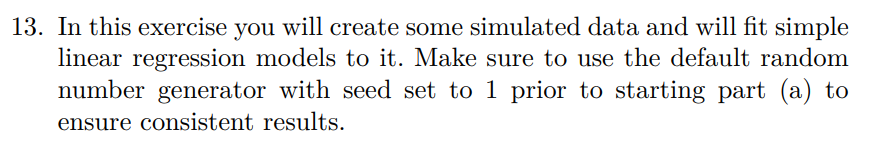
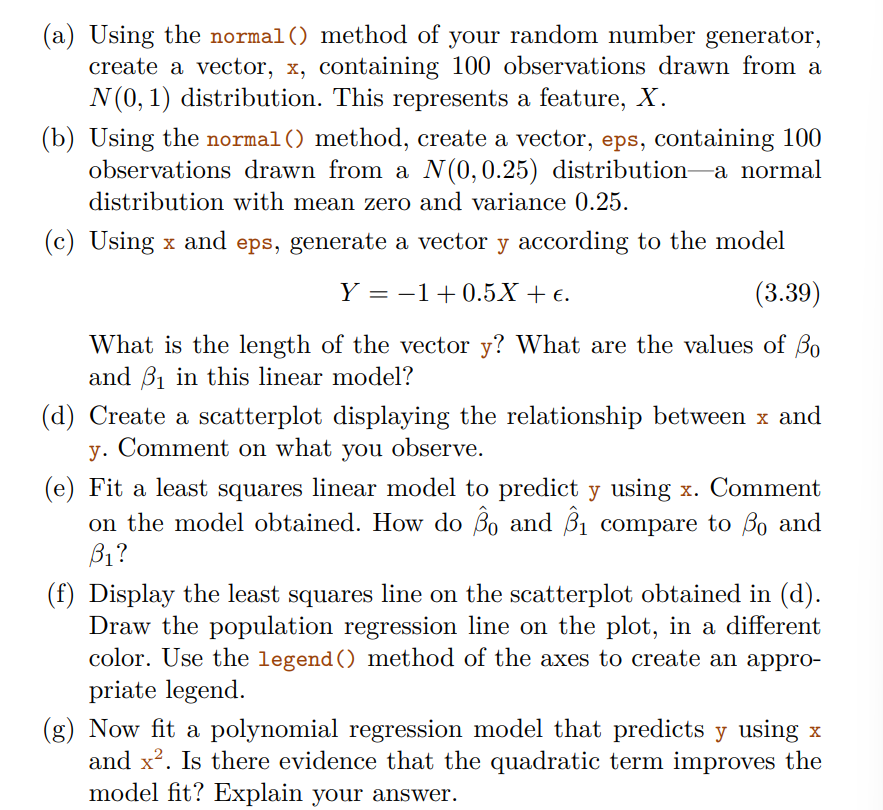
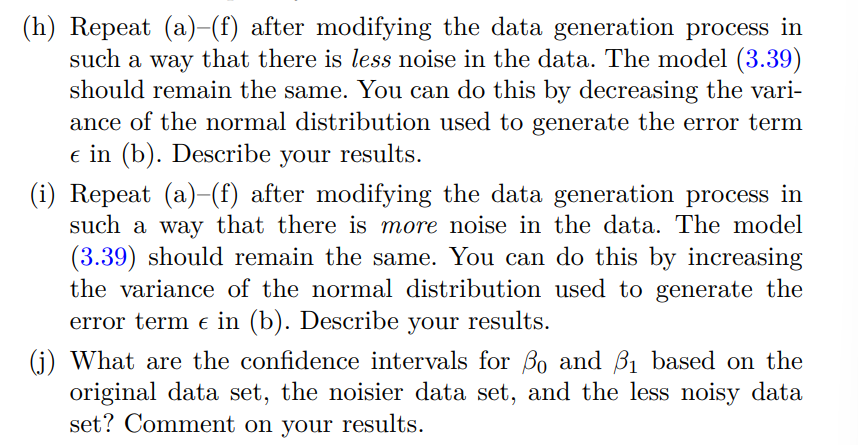
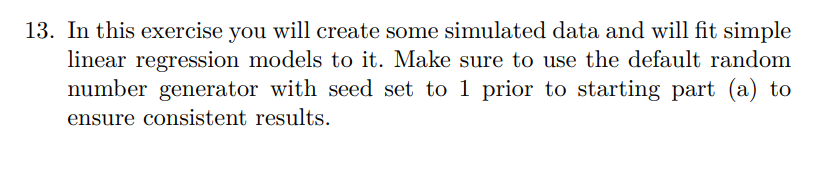

In [2]:
np.random.seed(1)
# loc -> Mean, scale -> std
x = np.random.normal(loc=0, scale=1,size=100)

In [3]:
eps = np.random.normal(loc=0, scale=0.25, size=100)

In [4]:
X = pd.DataFrame({'X1':x,
                   'X2':eps})
X.insert(0,'constant',1)

In [5]:
Y = pd.DataFrame({'Y':np.ones(shape=len(X['X1']))})
for i in range(0,len(X['X1'])):
    Y.loc[i,'Y']= -1 + 0.5*X['X1'].iloc[i] + X['X2'].iloc[i]

In [6]:
model= sm.OLS(Y,X).fit()
summarize(model)

,coef,std err,t,P>|t|
constant,-1.0,3.150000e-17,-3.180000e+16,0.0
X1,0.5,3.520000e-17,1.420000e+16,0.0
X2,1.0,1.340000e-16,7.480000e+15,0.0


In [7]:
X['X1'].min()

np.float64(-2.3015386968802827)

In [8]:
model.params.iloc[1]

np.float64(0.4999999999999999)

In [9]:
xlim= [min(X['X1']), max(X['X1'])]
ylim= [(model.params.iloc[0]+model.params.iloc[1]*xlim[0]), (model.params.iloc[0]+model.params.iloc[1]*xlim[1])]

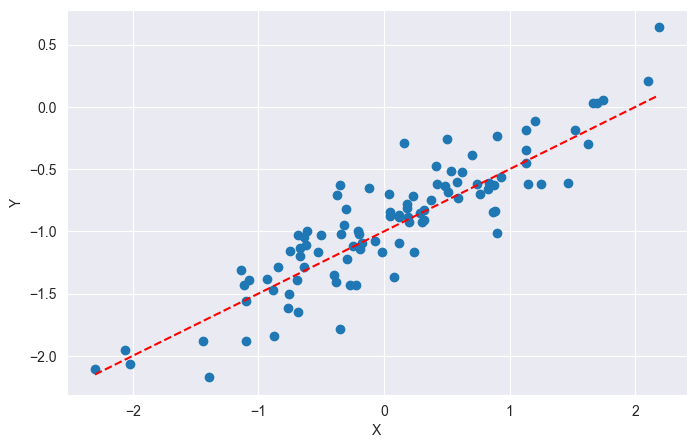

In [10]:
plt.figure(figsize=(8,5))
plt.scatter(y=Y, x=x)
plt.plot(xlim,ylim, 'r--')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

In [13]:
df1 = pd.DataFrame({'constant':np.ones(shape=X['X1'].shape),
                    'X':X['X1']})
model_y_x = sm.OLS(Y,df1).fit()

In [14]:
summarize(model_y_x)

,coef,std err,t,P>|t|
constant,-0.9632,0.023,-40.999,0.0
X,0.5239,0.026,19.783,0.0


In [15]:
summarize(model)

,coef,std err,t,P>|t|
constant,-1.0,3.150000e-17,-3.180000e+16,0.0
X1,0.5,3.520000e-17,1.420000e+16,0.0
X2,1.0,1.340000e-16,7.480000e+15,0.0


In [17]:
xlim1= [min(X['X1']), max(X['X1'])]
ylim1= [(model_y_x.params.iloc[0]+model_y_x.params.iloc[1]*xlim[0]), (model_y_x.params.iloc[0]+model_y_x.params.iloc[1]*xlim[1])]

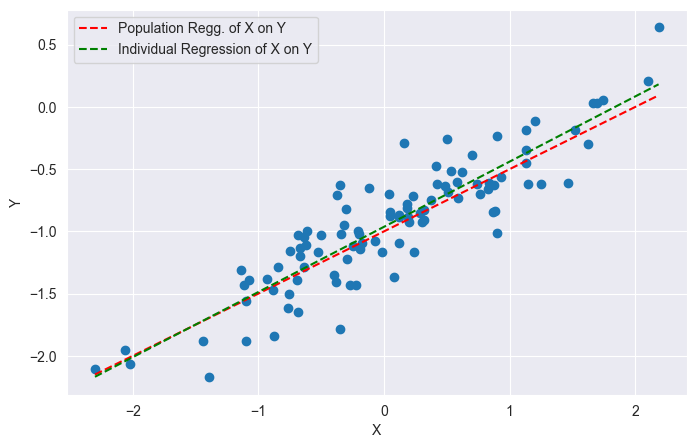

In [25]:
plt.figure(figsize=(8,5))
plt.scatter(y=Y, x=x)
plt.plot(xlim,ylim, 'r--', label="Population Regg. of X on Y")
plt.plot(xlim1,ylim1,'g--', label="Individual Regression of X on Y")
plt.legend()
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

In [28]:
df2 = pd.DataFrame({'constant':np.ones(shape=X['X1'].shape),
                    'X':X['X1'],
                    'X_square':np.square(X['X1'])})
model_y_x_xsquare = sm.OLS(Y,df2).fit()

In [29]:
summarize(model_y_x_xsquare)

,coef,std err,t,P>|t|
constant,-0.9663,0.029,-33.486,0.000
X,0.5234,0.027,19.582,0.000
X_square,0.0039,0.021,0.181,0.856


In [33]:
model_y_x_xsquare.rsquared

np.float64(0.7998024699274676)

In [30]:
model_y_x.rsquared

np.float64(0.7997346204862734)

In [31]:
model.rsquared

np.float64(1.0)

## Decreasing the variance in the data

In [34]:
eps1 = np.random.normal(loc=0, scale=0.05, size=100)

In [35]:
X2 = pd.DataFrame({'X':x,
                   'error_term':eps1})
X2.insert(0,'constant',1)

In [36]:
model_lesser_noise = sm.OLS(Y,X2).fit()

In [37]:
summarize(model_lesser_noise)

,coef,std err,t,P>|t|
constant,-0.9638,0.023,-41.668,0.000
X,0.5258,0.026,20.155,0.000
error_term,0.9326,0.460,2.029,0.045


In [38]:
eps2 = np.random.normal(loc=0, scale=2, size=100)
X3 = pd.DataFrame({'X':x,
                   'error_term':eps2})
X3.insert(0,'constant',1)
model_more_noise = sm.OLS(Y,X3).fit()
summarize(model_more_noise)

,coef,std err,t,P>|t|
constant,-0.9634,0.024,-40.845,0.000
X,0.5227,0.027,19.587,0.000
error_term,-0.0056,0.011,-0.500,0.618
